In [1]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate



from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from DATA_CHECK import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 




warng pyCloudy config: pyCloudy works better with matplotlib Triangulation


In [9]:
alpha = 0.969
R0 = -2.208 
R = 2140e5 # km 
Rsun = 696340e3  
T0 = 16225 
beta = 0.389 
T = 46000

M = (R0 - np.log10(R/Rsun) + beta*np.log10(1+T/T0)) / alpha

# M = (R0 - np.log10(0.025) + beta*np.log10(1+30000/T0)) / alpha


print(10**M)

0.030515334122341236


1.7838743763136775e+42
1.783135859938205e+42


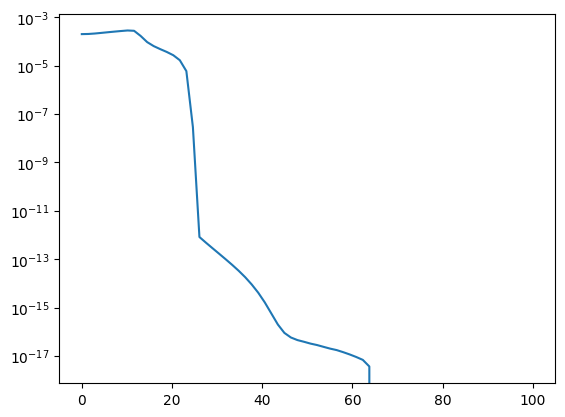

In [112]:
Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)
# print(f"n_H at 40 kpc = {n_h_40:.2e}" )

cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

emis = cloudy_data_2['emis_CIV']
radius = cloudy_data_2['radius']
radius_kpc = cloudy_data_2['radius_kpc']
# dr = cloudy_data_2['dr']


def SB(z, radius_kpc, emissivity):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin = np.trapezoid(2*np.pi*Project_R * surface_brightness, Project_R)
    
    return Project_R / kpc, surface_brightness, Lumin


Project_R, surface_brightness, Lumin = SB(0,radius_kpc,emis)

plt.plot(Project_R, surface_brightness)
plt.yscale('log')

print(cloudy_data_2['Lum_CIV'])
print(Lumin)

In [113]:
def SB(z, radius_kpc, emissivity):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin = np.trapezoid(2*np.pi*Project_R * surface_brightness, Project_R)
    
    return Project_R / kpc, surface_brightness, Lumin

# origin_SB = surface_brightness 
# CIV_lum = Lumin 
# radius = Project_R / kpc,

def photon_number_SB(radius, origin_SB, CIV_lum):
    """광자 수 기반 Surface Brightness 계산 함수"""
    try:
        if len(radius) < 2 or len(origin_SB) != len(radius):
            print("Error: Invalid input arrays for photon_number_SB")
            return np.array([0]), np.array([0])
            
        R_rt = radius / 100 
        dR = R_rt[1] - R_rt[0]
        number_dis = np.zeros(len(R_rt))
        surface_brightness_RT = np.zeros(len(R_rt))

        
        # 첫 번째 루프: number_dis 계산
        for ii, R in enumerate(R_rt):
            if R == 0:
                area = np.pi * (0.5*dR)**2
            elif R == R_rt[-1]:
                area = np.pi * (2*R + 0.5*dR) * 0.5*dR 
            else:
                area = 2*np.pi*R*dR
            number_dis[ii] = origin_SB[ii] * area 
            
        total_Number = np.sum(number_dis)
        if total_Number == 0:
            print("Warning: Total number is zero")
            return number_dis, surface_brightness_RT
            
        factor_atom = CIV_lum / total_Number 
        
        # 두 번째 루프: surface_brightness_RT 계산
        for ii, R in enumerate(R_rt):
            if R == 0:
                area = np.pi * (0.5*dR)**2
            elif R == R_rt[-1]:
                area = np.pi * (2*R + 0.5*dR) * 0.5*dR 
            else:
                area = 2*np.pi*R*dR
            factor_area = (100*kpc)**2
            surface_brightness_RT[ii] = number_dis[ii] * factor_atom / (area*factor_area) 

        Lumin_RT = np.trapezoid(2*np.pi*Project_R * surface_brightness_RT, Project_R)
        return number_dis, surface_brightness_RT, Lumin_RT
        
    except Exception as e:
        print(f"Error in photon_number_SB: {e}")
        return np.array([0]), np.array([0])



0.002608877197463133
0.002608379247939305


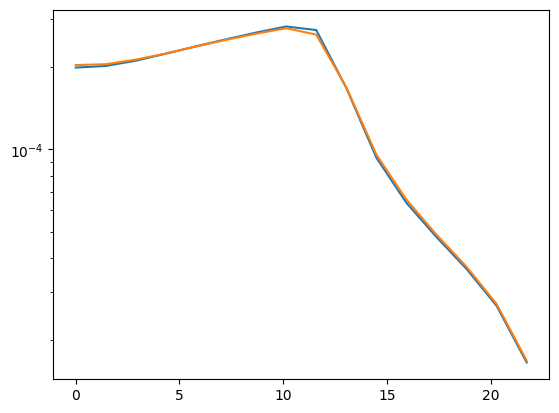

In [117]:


Lumin = 43.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 300
V_emit = 3000
V_rand = 30

path_RT = "/home/jin/RT/Data_metal"
atom = 'CIV'

geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
cloudy_data_2[f'Lumin_{atom}']
Project_R, surface_brightness, Lumin = SB(0,radius_kpc,emis)
number_dist_Ne, SB_Ne, Lum_Ne = photon_number_SB(radius_Ne,Num_SB_Ne,Lumin) 

ii = np.where(Project_R <= 22)[0]

plt.plot(Project_R[ii], surface_brightness[ii])
plt.plot(radius_Ne[ii],SB_Ne[ii])
plt.yscale('log')

print(np.sum(surface_brightness))
print(np.sum(SB_Ne))

0.002608877197463133
0.0026144835827435725


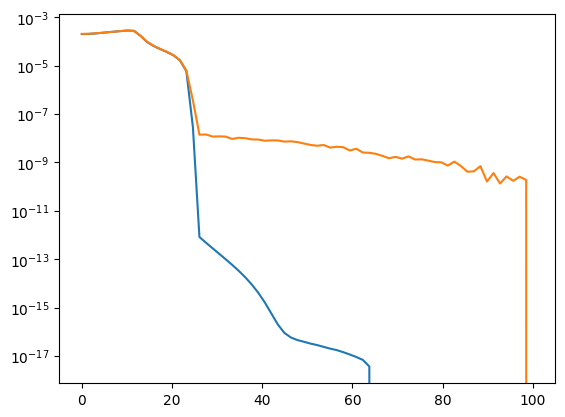

In [108]:
Lumin = 43.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 300
V_emit = 3000
V_rand = 30

path_RT = "/home/jin/RT/Data_metal"
atom = 'CIV'

geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
cloudy_data_2[f'Lumin_{atom}']
Project_R, surface_brightness, Lumin = SB(0,radius_kpc,emis)
number_dist_Ne, SB_Ne, Lum_Ne = photon_number_SB(radius_Ne,Num_SB_Ne,Lumin) 

ii = np.where(Project_R <= 22)[0]

plt.plot(Project_R, surface_brightness)
plt.plot(radius_Ne,SB_Ne)
plt.yscale('log')

print(np.sum(surface_brightness))
print(np.sum(SB_Ne))
# 문제: ii는 np.where로 생성된 인덱스 배열임. 
# surface_brightness[:ii]는 배열 슬라이싱에 배열을 쓸 수 없으므로 에러 발생.
# 해결: ii가 인덱스 배열이므로 surface_brightness[ii]처럼 마스킹 연산 사용.
# SB_r_22_cloudy = np.sum(surface_brightness[ii])
# SB_r_over_22_cloudy = np.sum(surface_brightness[ii.max()+1:])

# SB_r_22_rt = np.sum(SB_Ne[ii])
# SB_r_over_22_rt = np.sum(SB_Ne[ii.max()+1:])

# print(SB_r_22_cloudy)
# print(SB_r_22_rt)

# print(Lum_Ne)
# plt.plot(radius_Ne,Lum_Ne)
# print(np.sum(Lum_Ne))
# plt.ylim(1e-4,1e-3)
# plt.axvline(23,0,1)


ValueError: too many values to unpack (expected 2)

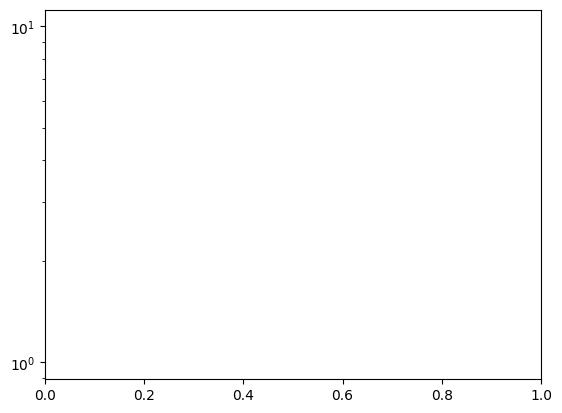

In [ ]:
Lumin = 43.5
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
geo = "Nebula"
V_out = 500
V_emit = 3000
V_rand = 30

path_RT = "/home/jin/RT/Data_metal"
atom = 'CIV'

geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]

# plt.plot(radius_Ne,Num_SB_Ne)

plt.yscale('log')
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne,cloudy_data_2[f'Lumin_{atom}']) 
print(cloudy_data_2[f'Lumin_{atom}'])

plt.plot(Project_R, surface_brightness)
plt.plot(radius_Ne,SB_Ne)





r_min, r_max = radius_kpc.min(), radius_kpc.max()

def lumin_integrand(R):
    dR =  Project_R[1] - Project_R[0]   

    if R == 0 :
        area = np.pi * (0.5*dR)**2
    elif R == r_max:
        area = np.pi * (2*R +0.5*dR)*0.5*dR 
    else:
        area = 2 * np.pi * R * np.interp(R, radius_Ne, SB_Ne)
    
    return area

Lumin_rt, _ = quad(lumin_integrand, 0, r_max)
print(Lumin_rt)

# print(Project_R)

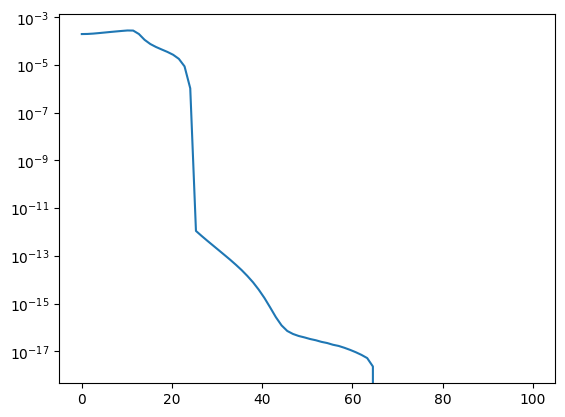

In [ ]:
def RT_SB(path):
    path_sb = f'{path}radi.dat'
    # print(path_sb)
    """RT 산출물에서 Surface Brightness 데이터를 읽어오는 함수"""
    if not os.path.exists(path_sb):
        print(f"Warning: RT file not found: {path_sb}")
        return None
    
    try:
        name = ['radius','SB_K','SB_H','SB_tot','1','2','3']
        data_sp = pd.read_csv(path_sb, sep='\s+', header=None,names=name)
        rad, SB_t, SB_k,SB_h =  data_sp['radius'].to_numpy(),data_sp['SB_tot'].to_numpy(),data_sp['SB_K'].to_numpy(),data_sp['SB_H'].to_numpy()
        # print('radius, rdius[kpc], Surface_Brightness_Total')
        return rad*100, rad*100*kpc, SB_t 
    except Exception as e:
        print(f"Error reading RT file {path_sb}: {e}")
        return None 




def photon_number_SB(radius, origin_SB, CIV_lum):
    """광자 수 기반 Surface Brightness 계산 함수"""
    try:
        if len(radius) < 2 or len(origin_SB) != len(radius):
            print("Error: Invalid input arrays for photon_number_SB")
            return np.array([0]), np.array([0])
            
        R_rt = radius / 100 
        dR = R_rt[1] - R_rt[0]
        number_dis = np.zeros(len(R_rt))
        surface_brightness_RT = np.zeros(len(R_rt))
        
        # 첫 번째 루프: number_dis 계산
        for ii, R in enumerate(R_rt):
            if R == 0:
                area = np.pi * (0.5*dR)**2
            elif R == R_rt[-1]:
                area = np.pi * (2*R + 0.5*dR) * 0.5*dR 
            else:
                area = 2*np.pi*R*dR
            number_dis[ii] = origin_SB[ii] * area 
            
        total_Number = np.sum(number_dis)
        if total_Number == 0:
            print("Warning: Total number is zero")
            return number_dis, surface_brightness_RT
            
        factor_atom = CIV_lum / total_Number 
        
        # 두 번째 루프: surface_brightness_RT 계산
        for ii, R in enumerate(R_rt):
            if R == 0:
                area = np.pi * (0.5*dR)**2
            elif R == R_rt[-1]:
                area = np.pi * (2*R + 0.5*dR) * 0.5*dR 
            else:
                area = 2*np.pi*R*dR
            factor_area = (100*kpc)**2
            surface_brightness_RT[ii] = number_dis[ii] * factor_atom / (area*factor_area) 

        return number_dis, surface_brightness_RT
        
    except Exception as e:
        print(f"Error in photon_number_SB: {e}")
        return np.array([0]), np.array([0])



number_dis, sb_rt = photon_number_SB(Project_R, surface_brightness, Lumin)
# surface_brightness
plt.plot(Project_R,sb_rt)
plt.yscale('log')